In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder


In [5]:
df = pd.read_csv(r"D:\Organ D-R matching prediction system\organ_transplant_15000_records.csv")

# View first 5 rows
print(df.head())

   Donor_Age  Recipient_Age Donor_Blood Recipient_Blood Organ_Type  \
0         21             35           O              AB      Liver   
1         39             21           A               A      Liver   
2         45             67           O              AB     Kidney   
3         23             60           A               A     Kidney   
4         48             20           B               B       Lung   

  Urgency_Level HLA_Match  Severity_Score Donor_Organ_Quality  \
0           Low       Low               4                Poor   
1          High    Medium               2                Good   
2           Low    Medium               4                Good   
3        Medium    Medium               5             Average   
4        Medium       Low               5                Poor   

   Compatibility_Score Match_Outcome  
0                   72  Not Suitable  
1                   30  Not Suitable  
2                   35  Not Suitable  
3                   63  Not Suit

In [6]:
print(df.info()) #checkingdatasetinfo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Donor_Age            15000 non-null  int64 
 1   Recipient_Age        15000 non-null  int64 
 2   Donor_Blood          15000 non-null  object
 3   Recipient_Blood      15000 non-null  object
 4   Organ_Type           15000 non-null  object
 5   Urgency_Level        15000 non-null  object
 6   HLA_Match            15000 non-null  object
 7   Severity_Score       15000 non-null  int64 
 8   Donor_Organ_Quality  15000 non-null  object
 9   Compatibility_Score  15000 non-null  int64 
 10  Match_Outcome        15000 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.3+ MB
None


In [7]:
print(df["Match_Outcome"].value_counts()) #classdistribution

Match_Outcome
Not Suitable    13463
Suitable         1537
Name: count, dtype: int64


In [8]:
encoder = LabelEncoder()

categorical_cols = [
    "Donor_Blood",
    "Recipient_Blood",
    "Organ_Type",
    "Urgency_Level",
    "HLA_Match",
    "Donor_Organ_Quality",
    "Match_Outcome"
]

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])  #encoding

In [9]:
print(df.head()) #afterencoding

   Donor_Age  Recipient_Age  Donor_Blood  Recipient_Blood  Organ_Type  \
0         21             35            3                1           1   
1         39             21            0                0           1   
2         45             67            3                1           0   
3         23             60            0                0           0   
4         48             20            2                2           2   

   Urgency_Level  HLA_Match  Severity_Score  Donor_Organ_Quality  \
0              1          1               4                    2   
1              0          2               2                    1   
2              1          2               4                    1   
3              2          2               5                    0   
4              2          1               5                    2   

   Compatibility_Score  Match_Outcome  
0                   72              0  
1                   30              0  
2                   35          

In [11]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [12]:
print(df.head())

   Donor_Age  Recipient_Age  Donor_Blood  Recipient_Blood  Organ_Type  \
0         21             35            3                1           1   
1         39             21            0                0           1   
2         45             67            3                1           0   
3         23             60            0                0           0   
4         48             20            2                2           2   

   Urgency_Level  HLA_Match  Severity_Score  Donor_Organ_Quality  \
0              1          1               4                    2   
1              0          2               2                    1   
2              1          2               4                    1   
3              2          2               5                    0   
4              2          1               5                    2   

   Compatibility_Score  Match_Outcome  
0                   72              0  
1                   30              0  
2                   35          

In [13]:
# Input features (all except Match_Outcome)
X = df.drop("Match_Outcome", axis=1)

# Target variable (what we predict)
y = df["Match_Outcome"]

In [14]:
print(X.shape)
print(y.shape)

(15000, 10)
(15000,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
print(X_train.shape)
print(X_test.shape)

(12000, 10)
(3000, 10)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test) #trainlogisticregression

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test) #traindecisiontreeclassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test) #trainrandomforestclassifier

In [20]:
print(rf_pred[:10])

[0 0 0 0 1 0 0 0 1 0]


In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.8973333333333333
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


In [22]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2697
           1       1.00      1.00      1.00       303

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [23]:
cm = confusion_matrix(y_test, rf_pred)
print(cm)

[[2697    0]
 [   0  303]]


In [25]:
pip install seaborn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - ----------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


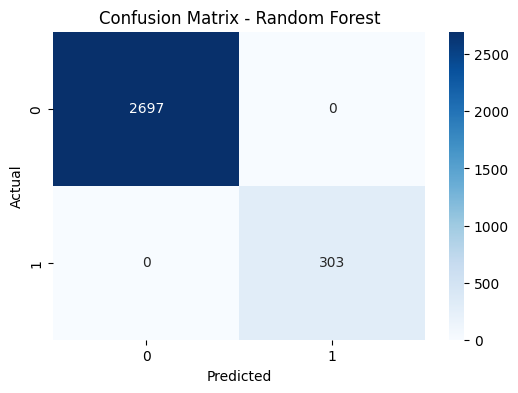

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [29]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.897333
1        Decision Tree  1.000000
2        Random Forest  1.000000


In [30]:
# Create new input (same columns as training data)

new_case = pd.DataFrame([{
    "Donor_Age": 40,
    "Recipient_Age": 45,
    "Donor_Blood": 3,           # encoded value
    "Recipient_Blood": 3,
    "Organ_Type": 1,            # Kidney/Liver/Lung encoded
    "Urgency_Level": 2,         # High
    "HLA_Match": 2,             # High
    "Severity_Score": 4,
    "Donor_Organ_Quality": 0,   # Good
    "Compatibility_Score": 85
}])

In [35]:
prediction = rf.predict(new_case)

if prediction[0] == 1:
    print("Prediction: Suitable Match")
else:
    print("Prediction: Not Suitable Match") #showoutput

prob = rf.predict_proba(new_case)

confidence = max(prob[0])  # highest probability

print("Confidence Score:", round(confidence, 2)) 

Prediction: Suitable Match
Confidence Score: 0.97


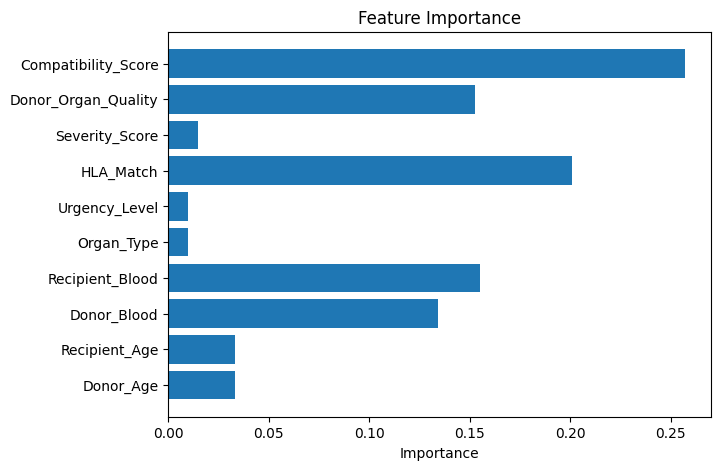

In [37]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(7,5))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show() #featureimportance

In [38]:
new_case = pd.DataFrame([{
    "Donor_Age": 38,
    "Recipient_Age": 42,
    "Donor_Blood": 0,          # A
    "Recipient_Blood": 0,      # A
    "Organ_Type": 0,           # Liver
    "Urgency_Level": 2,        # High
    "HLA_Match": 2,            # High
    "Severity_Score": 5,
    "Donor_Organ_Quality": 0,  # Good
    "Compatibility_Score": 90
}]) #likelysuitableliver

In [50]:
prediction = rf.predict(new_case)
prob = rf.predict_proba(new_case)

if prediction[0] == 1:
    print("Prediction: Suitable Match")
else:
    print("Prediction: Not Suitable Match")

print("Confidence Score:", round(max(prob[0]), 2))

Prediction: Not Suitable Match
Confidence Score: 0.9


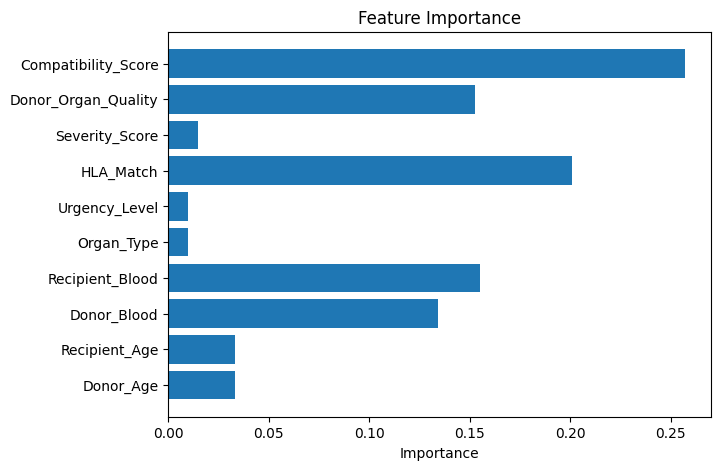

In [40]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(7,5))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show() #featureimportance

In [41]:
new_case = pd.DataFrame([{
    "Donor_Age": 50,
    "Recipient_Age": 30,
    "Donor_Blood": 0,          # A
    "Recipient_Blood": 2,      # B (mismatch)
    "Organ_Type": 1,           # Kidney
    "Urgency_Level": 1,        # Medium
    "HLA_Match": 0,            # Low
    "Severity_Score": 3,
    "Donor_Organ_Quality": 2,  # Poor
    "Compatibility_Score": 55
}]) #bloodmismatchnotsuitable

In [49]:
prediction = rf.predict(new_case)
prob = rf.predict_proba(new_case)

if prediction[0] == 1:
    print("Prediction: Suitable Match")
else:
    print("Prediction: Not Suitable Match")

print("Confidence Score:", round(max(prob[0]), 2))

Prediction: Not Suitable Match
Confidence Score: 0.9


In [46]:
new_case = pd.DataFrame([{
    "Donor_Age": 55,
    "Recipient_Age": 50,
    "Donor_Blood": 3,          # O
    "Recipient_Blood": 3,      # O
    "Organ_Type": 2,           # Lung
    "Urgency_Level": 1,        # Medium
    "HLA_Match": 1,            # Medium
    "Severity_Score": 3,
    "Donor_Organ_Quality": 1,  # Average
    "Compatibility_Score": 72
}])

In [48]:
prediction = rf.predict(new_case)
prob = rf.predict_proba(new_case)

if prediction[0] == 1:
    print("Prediction: Suitable Match")
else:
    print("Prediction: Not Suitable Match")

print("Confidence Score:", round(max(prob[0]), 2))

Prediction: Not Suitable Match
Confidence Score: 0.9
